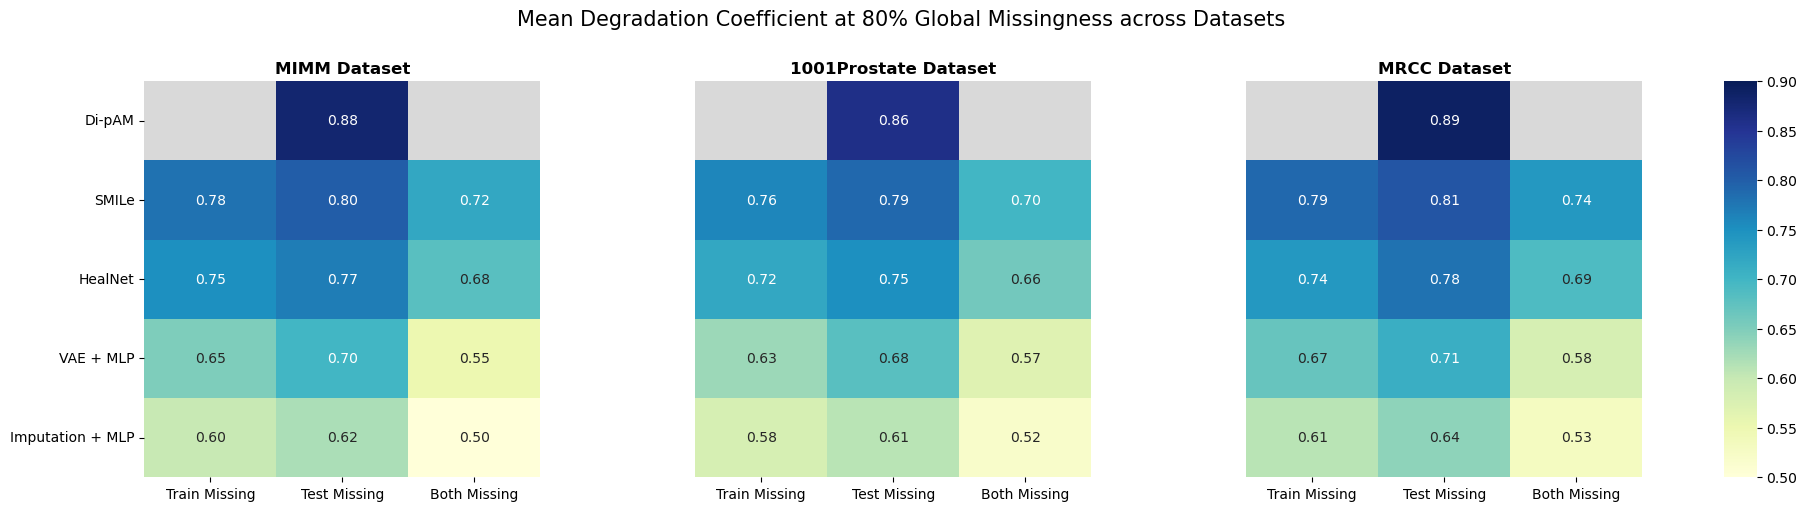

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuración de los datos (Simulados al 80% de missingness)
datasets = ['MIMM Dataset', '1001Prostate Dataset', 'MRCC Dataset']
models = ['Di-MMLP', 'SMILe', 'HealNet', 'VAE + MLP', 'Imputation + MLP']
setups = ['Train Missing', 'Test Missing', 'Both Missing']

dataset_matrices = [
    np.array([
        [np.nan, 0.88, np.nan],
        [0.78, 0.80, 0.72],
        [0.75, 0.77, 0.68],
        [0.65, 0.70, 0.55],
        [0.60, 0.62, 0.50],
    ]),
    np.array([
        [np.nan, 0.86, np.nan],
        [0.76, 0.79, 0.70],
        [0.72, 0.75, 0.66],
        [0.63, 0.68, 0.57],
        [0.58, 0.61, 0.52],
    ]),
    np.array([
        [np.nan, 0.89, np.nan],
        [0.79, 0.81, 0.74],
        [0.74, 0.78, 0.69],
        [0.67, 0.71, 0.58],
        [0.61, 0.64, 0.53],
    ]),
]

cmap = sns.color_palette('YlGnBu', as_cmap=True)
cmap.set_bad(color='#d9d9d9')

fig, axes = plt.subplots(
    1, 4, figsize=(18, 5), constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1, 1, 0.06]}
)
plot_axes = axes[:3]
cbar_ax = axes[3]

for i, ax in enumerate(plot_axes):
    data = dataset_matrices[i]

    sns.heatmap(
        data, annot=True, fmt='.2f', cmap=cmap, ax=ax,
        vmin=0.5, vmax=0.9,
        cbar=(i == 2), cbar_ax=cbar_ax if i == 2 else None,
        xticklabels=setups, yticklabels=models if i == 0 else []
    )
    ax.set_title(f'{datasets[i]}', fontsize=12, fontweight='bold')
    ax.set_box_aspect(1)

plt.suptitle('Mean Degradation Coefficient at 80% Global Missingness across Datasets\n', fontsize=15)
plt.show()

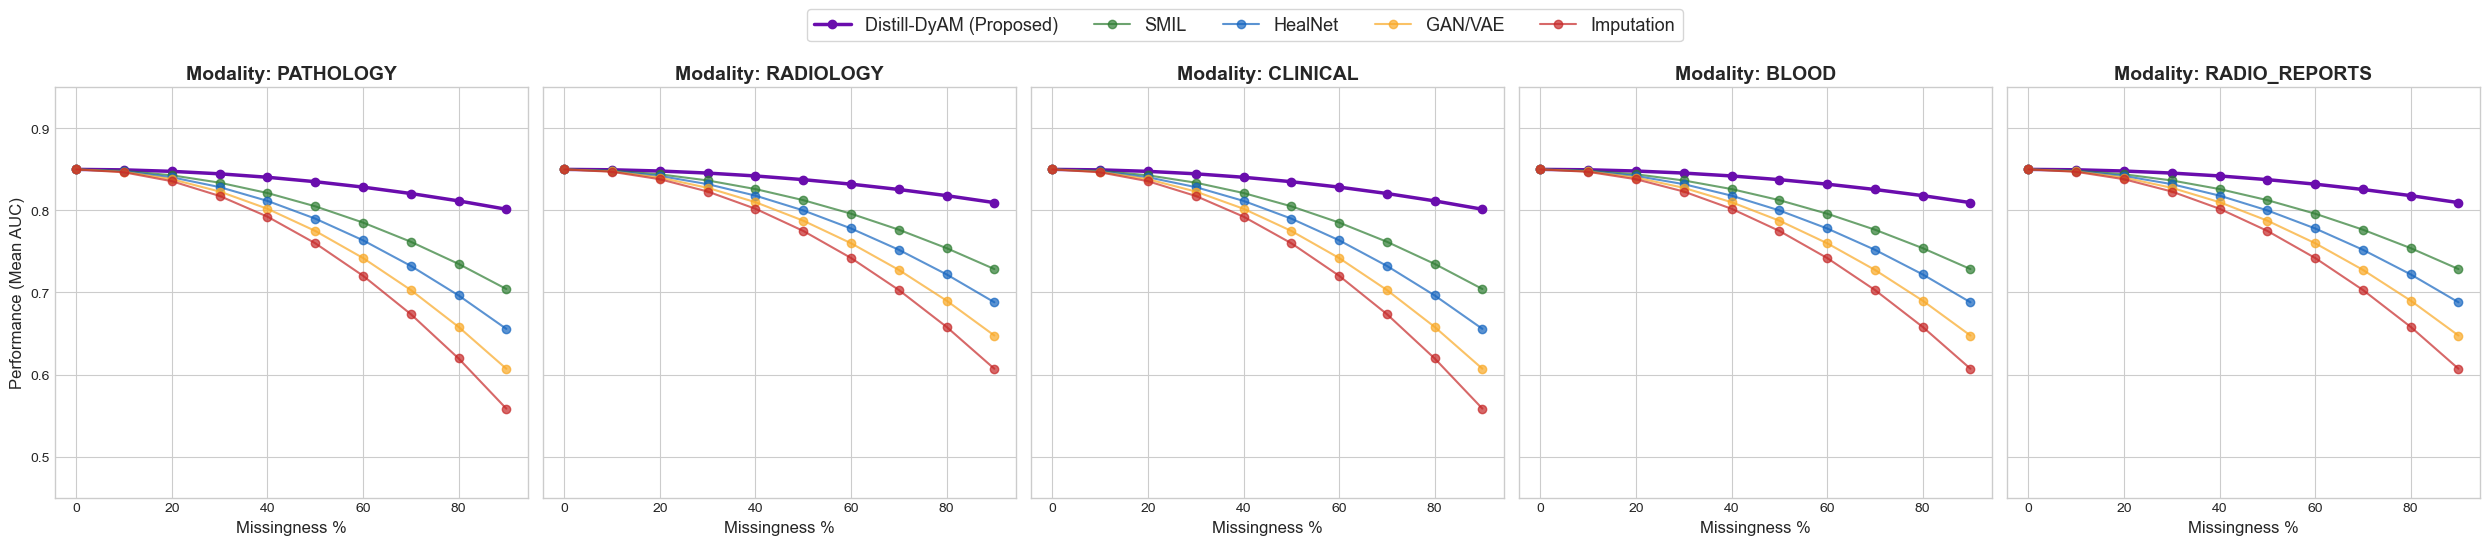

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Configuración de Modalidades y Modelos
modalities = ['PATHOLOGY', 'RADIOLOGY', 'CLINICAL', 'BLOOD', 'RADIO_REPORTS']
models = ['Distill-DyAM (Proposed)', 'SMIL', 'HealNet', 'GAN/VAE', 'Imputation']
x_missing = np.arange(0, 100, 10)  # 0% a 90%

# Configuración estética para TFM
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
colors = ['#6a0dad', '#2e7d32', '#1565c0', '#f9a825', '#c62828'] # Púrpura para tu modelo

# 2. Generación de Curvas (Simulación técnica)
for i, ax in enumerate(axes):
    mod = modalities[i]
    
    for m_idx, model in enumerate(models):
        # Generamos una curva de degradación (AUC que cae según missingness)
        # Distill-DyAM (m_idx=0) tiene la caída más suave
        base_auc = 0.85
        decay = 0.05 if m_idx == 0 else (0.1 + m_idx * 0.05)
        
        # Simulación de ruido: Clinical y Pathology suelen doler más al faltar
        if mod in ['CLINICAL', 'PATHOLOGY']:
            decay *= 1.2 
            
        y_auc = base_auc - (decay * (x_missing / 100)**2)
        y_auc = np.clip(y_auc, 0.5, 0.9) # No bajar de random guess (0.5)

        ax.plot(x_missing, y_auc, marker='o', label=model, 
                color=colors[m_idx], linewidth=2.5 if m_idx == 0 else 1.5,
                alpha=1.0 if m_idx == 0 else 0.7)

    # Estética de cada subplot
    ax.set_title(f'Modality: {mod}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missingness %', fontsize=12)
    if i == 0:
        ax.set_ylabel('Performance (Mean AUC)', fontsize=12)
    ax.set_ylim(0.45, 0.95)
    ax.set_xticks(np.arange(0, 100, 20))

# 3. Leyenda única superior para no saturar
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), 
           ncol=5, fontsize=13, frameon=True)

plt.tight_layout()
# Descomenta la siguiente línea para guardar la imagen con alta calidad
# plt.savefig('sensibilidad_modalidades.pdf', bbox_inches='tight', dpi=300)
plt.show()